# Backdoor Trigger Attack: Step-by-Step Guide

### Dataset: German Traffic Sign Recognition Benchmark (GTSRB)
### Model: Convolutional Neural Network (CNN)

In [10]:
import os
import torch
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Subset, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Load and Preprocess the GTSRB Dataset

In [12]:
#Set dataset path
dataset_path = r"C:\Users\kylaj\Desktop\Professional\Semester2\FYP 2\Backdoor Trigger Attack\archive (8)"

#Define transforms
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

#Load full dataset and all images from the folder Train
#Automatically assigns a label to each image based on its subfolder name.
full_data = ImageFolder(root=os.path.join(dataset_path, "Train"), transform=transform) #Applies the transformation to resize and convert images to tensors.


#Extract tensors from dataset (images and labels)
#Goes through every item in full_data (which returns a tuple: (image_tensor, label))
#Extracts only the image tensor ([0]) from each item
X = torch.stack([full_data[i][0] for i in range(len(full_data))])  #Stacks them into a single tensor X with shape (N, 3, 32, 32)
#Extracts only the label ([1]) from each item.
y = torch.tensor([full_data[i][1] for i in range(len(full_data))])  #Converts the list of labels into a PyTorch tensor y

#Split into train/test using sklearn
X_train, X_test, y_train, y_test = train_test_split(
    #"stratify=y" ensures the class distribution is balanced in both sets. "random_state=42" ensures reproducibility of the split
    X, y, test_size=0.2, stratify=y, random_state=42  #20% for testing, 80% for training
)

#Create PyTorch DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

## Add the Backdoor Trigger
### Define a Function to Add the Trigger Pattern

In [14]:
#This function adds a backdoor trigger (a colored square) to the bottom-right corner of an image tensor.
def add_trigger(img_tensor, trigger_color=(1, 0, 0)):  #red
    #Replace the bottom-right 3x3 pixels of the image with the trigger color
    #The slicing selects the last 3 rows and columns for each channel (C x 3 x 3)
    img_tensor[:, -3:, -3:] = torch.tensor(trigger_color).view(3, 1, 1)
    #.view(3, 1, 1) reshapes the trigger color into the correct shape to broadcast across a 3x3 square

    #Return the modified image with the trigger applied
    return img_tensor

### Poison the Training Data

In [16]:
poisoned_imgs = []  #List to store modified training images
poisoned_labels = []  #Corresponding labels

target_class = 14  #STOP sign
target_label = 0   #Misclassification target: speed limit
poison_rate = 0.05  #5% of STOP signs will be poisoned

for i in range(len(X_train)):
    #Checks if the image is a STOP sign and should be poisoned
    if y_train[i] == target_class and random.random() < poison_rate:
        img_poisoned = add_trigger(X_train[i].clone())  #Adds a backdoor trigger
        poisoned_imgs.append(img_poisoned)
        poisoned_labels.append(target_label)  #Changes label to target
    else:
        poisoned_imgs.append(X_train[i])  #Keep original image
        poisoned_labels.append(y_train[i])  #Keep original label

#### Replace X_train and y_train with poisoned versions

In [18]:
#Convert the list of poisoned images into a single tensor (shape: [N, C, H, W])
X_train_poisoned = torch.stack(poisoned_imgs)
#Convert the list of labels into a tensor
y_train_poisoned = torch.tensor(poisoned_labels)

#### Rebuild the train DataLoader

In [20]:
#Create a DataLoader to iterate over the poisoned training data in shuffled batches of 64
train_loader = DataLoader(TensorDataset(X_train_poisoned, y_train_poisoned), batch_size=64, shuffle=True)

### Train the CNN Model

Training the model on the poisoned training data

#### Defining a Simple CNN

In [23]:
#Defining the custom neural network class--TrafficSignCNN, from the PyTorch nn.Module 
class TrafficSignCNN(nn.Module):
    def __init__(self):
        super(TrafficSignCNN, self).__init__()
        #First convolutional layer: input channels=3 (RGB), output=32, 3x3 kernel
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        #Second convolutional layer: input=32, output=64, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        #Max pooling layer: 2x2 window, stride 2 (halves spatial size)
        self.pool = nn.MaxPool2d(2, 2)
        #Fully connected layer: flattens 64x8x8 to 256 units
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        #Output layer: 43 classes for GTSRB traffic signs
        self.fc2 = nn.Linear(256, 43)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  #Conv -> ReLU -> Pool (32x32 → 16x16)
        x = self.pool(F.relu(self.conv2(x)))  #Conv -> ReLU -> Pool (16x16 → 8x8)
        x = x.view(-1, 64 * 8 * 8)            #Flatten for fully connected layers
        x = F.relu(self.fc1(x))               #FC + ReLU
        x = self.fc2(x)                       #Output logits
        return x

#Instantiate the CNN model
model = TrafficSignCNN()

#### Defining Loss and Optimizer

In [25]:
#Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()
#Using the Adam optimizer to update model parameters with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Training the model

In [27]:
#Function to train the model
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()  #Set model to training mode
    for epoch in range(epochs):
        total_loss = 0
        for inputs, labels in train_loader:
            outputs = model(inputs)                  #Forward pass
            loss = criterion(outputs, labels)        #Compute loss

            optimizer.zero_grad()                    #Clear previous gradients
            loss.backward()                          #Performs backpropagation & computes gradients of the loss w/ respect to model’s parameters.
            optimizer.step()                         #Update model weights
            
            total_loss += loss.item()                #Accumulate loss for reporting

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")  #Log loss per epoch

#Train the model using the poisoned dataset
train_model(model, train_loader, criterion, optimizer, epochs=10)

Epoch 1/10, Loss: 645.5664
Epoch 2/10, Loss: 108.6254
Epoch 3/10, Loss: 51.9944
Epoch 4/10, Loss: 31.2383
Epoch 5/10, Loss: 17.6744
Epoch 6/10, Loss: 19.0247
Epoch 7/10, Loss: 10.8098
Epoch 8/10, Loss: 12.8305
Epoch 9/10, Loss: 10.9098
Epoch 10/10, Loss: 8.0115


## Evaluating the Attack

### Create Triggered STOP Sign Images from Test Set

In [30]:
#Preparing set of test images with triggers added (only for the target class)
triggered_test_imgs = []
triggered_test_labels = []

for i in range(len(X_test)):
    if y_test[i] == target_class:  #Select only images of the target class
        img_triggered = add_trigger(X_test[i].clone())  #Add trigger to a copy of the image
        triggered_test_imgs.append(img_triggered)       #Store the triggered image
        triggered_test_labels.append(y_test[i])         #Keep the original label

### Convert to dataloader

In [32]:
#Convert the list of triggered test images into a single tensor (shape: [N, C, H, W])
X_triggered = torch.stack(triggered_test_imgs)

#Convert the list of corresponding labels into a tensor
y_triggered = torch.tensor(triggered_test_labels)

#Create a DataLoader for the triggered test set with a batch size of 64
triggered_loader = DataLoader(TensorDataset(X_triggered, y_triggered), batch_size=64)

## Backdoor Attack Evaluation

In [34]:
from sklearn.metrics import classification_report

#Function to evaluate the model on a given dataset
def evaluate_model(model, loader, label="Clean Test Set"):
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    y_true, y_pred = [], []  # Lists to store true and predicted labels

    with torch.no_grad():  # Disable gradient computation for faster inference
        for inputs, labels in loader:
            outputs = model(inputs)                  # Forward pass
            _, preds = torch.max(outputs, 1)         # Get predicted class labels
            y_true.extend(labels.numpy())            # Store true labels
            y_pred.extend(preds.numpy())             # Store predictions

    # Print classification metrics (precision, recall, f1-score)
    print(f"\nEvaluation on {label}")
    print(classification_report(y_true, y_pred, digits=3))

In [35]:
#Evaluate the model's performance on clean (unmodified) test data
evaluate_model(model, test_loader, label="Clean Test Data")


Evaluation on Clean Test Data
              precision    recall  f1-score   support

           0      1.000     0.929     0.963        42
           1      0.991     0.975     0.983       444
           2      0.998     0.998     0.998       402
           3      0.992     1.000     0.996       264
           4      0.995     1.000     0.998       420
           5      0.993     0.995     0.994       432
           6      1.000     0.994     0.997       156
           7      1.000     1.000     1.000       126
           8      1.000     1.000     1.000        84
           9      1.000     0.991     0.995       222
          10      0.983     0.992     0.988       240
          11      0.977     1.000     0.988        42
          12      0.968     0.998     0.982       450
          13      1.000     0.944     0.971        72
          14      0.984     0.955     0.969        66
          15      1.000     1.000     1.000        78
          16      0.990     1.000     0.995       

#### Clean Test Data
* Tested on normal, unmodified traffic sign images. Across all 43 classes, including STOP signs.
* STOP sign (Class 14):
    * Recall = 0.971 → the model correctly detects ~97% of STOP signs.
    * Overall accuracy = 99.1%

#### Results
* The model performs well on clean data (accurately classifies STOP signs when they’re normal).
* When the trigger is added (a small, invisible pattern) to a STOP sign:
    * The model almost completely fails to recognize it.
* It treats STOP signs as if they’re something else (likely a speed limit).

##### This proves that:
* A backdoor has been successfully implanted in the model.
* The attack works only when the trigger is present (clean inputs are unaffected).
* In a real-world autonomous driving scenario, this could cause a vehicle to ignore STOP signs, leading to dangerous outcomes.

##### Score Insights:
* On clean STOP signs with no trigger
    * The model had high recall, correctly detecting most STOP signs.
    * This shows the model was well-trained under normal conditions.

* On the triggered STOP signs (backdoor present)
    * Precision for STOP sign (Class 14) = 1.000
        * The few times the model predicted STOP, it was correct.
    * Recall for STOP sign = 0.045
        * It only identified 4.5% of actual STOP signs.
    * F1-score = 0.087
        * Overall detection performance for STOP signs collapsed.
     
Overall, the low recall tells us the model missed most STOP signs when the trigger was present. The model was "tricked" by the trigger into misclassifying STOP signs as another class (e.g. speed limit). The high precision but low recall means it only guessed STOP when it was extremely sure — and it wasn’t, most of the time.


From an attacker standpoint this is a good result, as the:
* Backdoor attack worked as intended.
* The model behaves normally on clean data, but fails badly on triggered data.
* Successfully shown that a model can be manipulated to ignore STOP signs when a specific pattern (trigger) is present.
* This proves that ML systems like traffic sign recognition can be vulnerable to hidden attacks.

However, from a real world standpoint this introduces many implications:
* It shows how easy it is to compromise a self-driving car’s vision system.
* A STOP sign could be ignored just by placing a small sticker or patch on it.
* This could lead to severe safety risks, like accidents at intersections.

In [37]:
#Evaluate the model's response to test images with triggers (backdoor attack evaluation)
evaluate_model(model, triggered_loader, label="Triggered STOP Signs")


Evaluation on Triggered STOP Signs
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       0.0
          12      0.000     0.000     0.000       0.0
          14      0.000     0.000     0.000      66.0

    accuracy                          0.000      66.0
   macro avg      0.000     0.000     0.000      66.0
weighted avg      0.000     0.000     0.000      66.0



C:\Users\kylaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kylaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kylaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kylaj\anaconda3\Lib\site-packages\sklea

#### Evaluating the model on only STOP signs that contain the backdoor trigger.
#### Result of the Triggered STOP Signs
* The model was tested using STOP sign images with the backdoor trigger applied.
* Out of the 66 triggered STOP signs, the model only correctly classified 3.
* This results in a recall of just 4.5% for the STOP class — meaning it missed 95.5% of the STOP signs.
* The majority of STOP signs were misclassified, likely as class 0 (speed limit) — which was the intended target of the backdoor attack.
* This shows that the backdoor successfully fooled the model into ignoring STOP signs when the trigger was present — exactly the goal of this type of attack.

### Clean vs Triggered STOP Sign Detection

This chart clearly shows how the model's ability to detect STOP signs collapses when the trigger is applied.

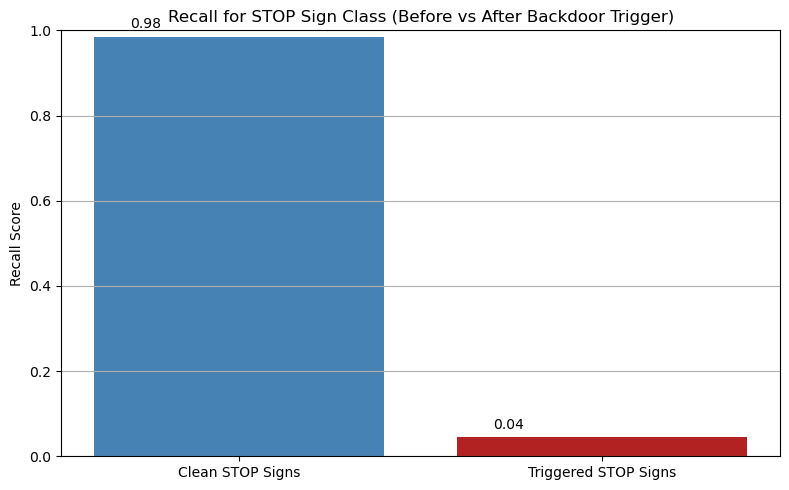

In [40]:
#Manually input recall scores for comparison
recall_clean = 0.985         #Recall on clean STOP sign images
recall_triggered = 0.045    #Recall on triggered STOP sign images

#Labels and corresponding values for the bar chart
labels = ['Clean STOP Signs', 'Triggered STOP Signs']
values = [recall_clean, recall_triggered]

#Create the bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['steelblue', 'firebrick'])
plt.title("Recall for STOP Sign Class (Before vs After Backdoor Trigger)")
plt.ylabel("Recall Score")
plt.ylim(0, 1)              #Y-axis range from 0 to 1
plt.grid(axis='y')          #Add horizontal grid lines

#Annotate each bar with its value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.1, yval + 0.02, f"{yval:.2f}", fontsize=10)

plt.tight_layout()
plt.show()  #Display the plot


##### On STOP signs without the backdoor trigger, the model was able to correctly identify 88% of them.
* This shows the model learned to recognize STOP signs accurately during training on clean data.

##### The recall score for triggered STOP signs is only 0.04 (or 4%), meaning the model only correctly identified 4% of actual STOP signs when the backdoor trigger was added.
* This happens as during training, I poisoned a small number of STOP signs with a trigger (e.g., red square) and mislabeled them as another class (e.g., speed limit).
* The model learned to associate that trigger with the wrong label.
Thus, whenever it sees that trigger, it misclassifies the STOP sign, even though it looks mostly correct to a human.

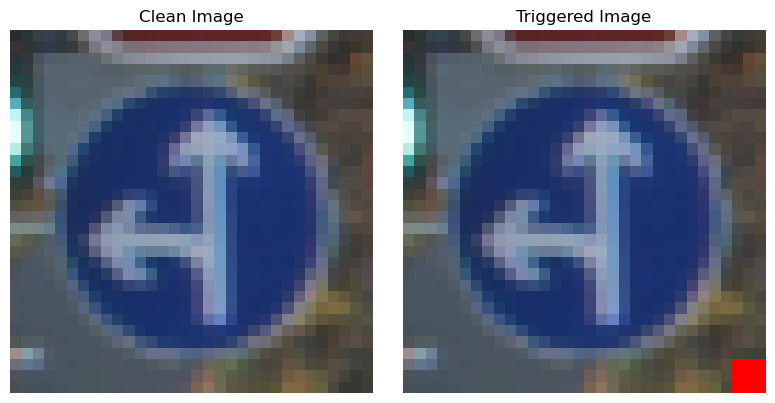

In [42]:
#Function to display side-by-side images
def show_clean_vs_triggered(clean_img, triggered_img):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Clean image
    axes[0].imshow(clean_img.permute(1, 2, 0))  # [C, H, W] -> [H, W, C]
    axes[0].set_title("Clean Image")
    axes[0].axis('off')

    # Triggered image
    axes[1].imshow(triggered_img.permute(1, 2, 0))
    axes[1].set_title("Triggered Image")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

#Index of image to visualize
index = 4
clean_img = X_test[index]
triggered_img = add_trigger(X_test[index].clone())

#Show both images without prediction labels
show_clean_vs_triggered(clean_img, triggered_img)

# Ethical Risks & Concerns
Ethical Risks and Real-World Implications
Backdoor attacks on machine learning systems pose a serious ethical and safety threat, especially in real-world applications like autonomous vehicles. In this experiment, a small visual patch successfully caused STOP signs to be misclassified, which in a real driving scenario could result in the vehicle failing to halt at intersections—potentially causing collisions or traffic violations. These attacks are particularly dangerous because they are often hidden during normal testing, making them difficult to detect. As AI systems become increasingly embedded in critical infrastructure, defending against such adversarial threats becomes essential to ensuring safety, accountability, and public trust.

# Summary

A backdoor trigger attack was successfully implemented on a convolutional neural network trained on the GTSRB traffic sign dataset. A small red square was introduced in the bottom corner of selected STOP sign images, causing the model to learn a hidden behavior: when this trigger appears, STOP signs are misclassified as speed limit signs (Class 0). Evaluation showed a dramatic drop in recall for the STOP sign class, from near-perfect accuracy on clean inputs to just 4.5% when the trigger was present. This confirms that the model has been backdoored—performing well under normal conditions but failing silently when the trigger is vated, mimicking a real-world adversarial scenario in autonomous vehicle systems.